# RSM338 Assignment 5
## March 25, 2026
### Ethan Wang, Kevin Yang

## 1. Data Preparation

In [26]:
# Load in the data
import pandas as pd

df = pd.read_excel('lending_clubFull_Data_Set.xlsx')
df

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,263591,545710,20000.0,60 months,17.93,342.94,E,E5,Wylie ISD,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,1,1613916,69664096,30000.0,36 months,11.99,996.29,C,C1,Sergeant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,2,818934,8965180,21500.0,36 months,11.99,714.01,B,B3,Designer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,3,1606612,70572960,10000.0,36 months,13.67,340.18,C,C3,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,4,1639932,68589517,5000.0,36 months,8.49,157.82,B,B1,Sr. Manufacturing Engineer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,901888,4974773,10500.0,36 months,10.16,339.60,B,B1,Schneider Electric,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24996,24996,945413,1279809,12000.0,36 months,14.33,412.06,C,C1,Clark County School District,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24997,24997,366944,63496281,25000.0,36 months,12.69,838.63,C,C2,sales consultant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24998,24998,1043529,98124387,12200.0,60 months,13.49,280.66,C,C2,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


Now that we loaded the data, we must  choose useful features for our analysis. As stated, many of the columns are redundant, so we should try to make our dataset more managable before our analysis.

### 1.1 Defining the Target Variable
We need a binary outcome for the loans - default or not - but we are given several outcomes. Let's first see all the unique loan outcomes.

In [27]:
# Display all unique values in the 'loan_status' column
unique_loan_status = df['loan_status'].unique()
unique_loan_status

array(['Charged Off', 'Current', 'Fully Paid', 'Late (31-120 days)',
       'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off', 'Default',
       nan], dtype=object)

After some brief research, we decided to define the following loan outcomes as default:

**['Charged Off', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']**

We believe that these are either explicitly defaulted, or highly likely to be defaulted. The rest of the outcomes are either paid off, being paid on time, or still recoverable. Going forward in our code, default loans will be represented using a dummy equal to 1.

### 1.2 Selecting Features
The features we have decided to select are:

[*'delinq_2yrs', 'annual_inc', 'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'dti', 'loan_amnt', 'home_ownership', 'emp_length'*]

These features can be grouped as follows:

**Past Behaviour**

*'delinq_2yrs' (delinquencies in the last 2 years)* and *'pct_tl_nvr_dlq' (percent of trades never delinquent)* tell us about the borrower's previous behaviour. Having one or more delinquencies in the past, especially relatively recent ones, signal higher credit risk. It tells us that the borrower may have questionable self-judgement on their ability to repay debts.

**Repaying Power**

*'annual_inc' (annual income)* and *'dti'(monthly debt-to-income ratio)* tells us about the earning power of the borrower. Even if a borrower has unfortunate circumstances that may affect their payments, if they have a strong basis for their ability to repay, then it is very possible for the debt to be recovered over time.

**Stability**

*'home_ownership' (ownership status i.e., rent, mortgage)* and *'emp_length' (in years, 0-10)* tell us if the borrower has a stable life. Borrowers with stability in their lives will have much more predictable repayments compared to one who is constantly moving and/or job-hopping.

**Loan Risk**

*'loan_amnt' (the amount applied for by borrower)* tells us about the borrower's perceived debt capacity. If a borrower has external signals that suggest credit risk, but they perceive the repayments to be feasible, it may suggest the borrower has an appetite for risk, which is unattractive to lendors. It also tells us the overall burden of the loan on the borrower, not just if they can make payments in the short-term.

### 1.3 Handling Missing Values and Data Types 

In [28]:
# 1. Handle missing values (Example: dropping rows with any NAs in selected features)
features_to_use = ['delinq_2yrs', 'annual_inc', 'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'dti', 'loan_amnt', 'home_ownership', 'emp_length', 'loan_status']
df_cleaned = df[features_to_use].dropna()
df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,home_ownership,emp_length,loan_status
1,3.0,136000.0,1.0,90.0,20.63,30000.0,MORTGAGE,10+ years,Current
2,0.0,50000.0,0.0,100.0,29.62,21500.0,RENT,1 year,Fully Paid
4,0.0,88000.0,1.0,60.0,5.32,5000.0,MORTGAGE,10+ years,Current
5,0.0,38500.0,0.0,100.0,33.73,16150.0,RENT,10+ years,Charged Off
6,0.0,40000.0,0.0,100.0,19.11,18400.0,RENT,8 years,Current


Theoretically, no applicant should have missing values in any of the columns. Missing values here, like income, would be highly problematic, as it should just be 0, not NaN. Therefore, we feel comfortable dropping all missing values from the data.

In [29]:
# Display all unique values in the 'home_ownership' column
unique_home_status = df['home_ownership'].unique()
unique_home_status

array(['MORTGAGE', 'RENT', 'OWN', 'ANY', 'OTHER', 'NONE', nan],
      dtype=object)

In [30]:
# Selecting categorical columns
categorical_cols = ['home_ownership']

# Perform One-Hot Encoding
# drop_first=True to avoid the "Dummy Variable Trap" 
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,emp_length,loan_status,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
1,3.0,136000.0,1.0,90.0,20.63,30000.0,10+ years,Current,True,False,False,False,False
2,0.0,50000.0,0.0,100.0,29.62,21500.0,1 year,Fully Paid,False,False,False,False,True
4,0.0,88000.0,1.0,60.0,5.32,5000.0,10+ years,Current,True,False,False,False,False
5,0.0,38500.0,0.0,100.0,33.73,16150.0,10+ years,Charged Off,False,False,False,False,True
6,0.0,40000.0,0.0,100.0,19.11,18400.0,8 years,Current,False,False,False,False,True


We decided to encode home ownership status to have dummies for each status. While it would have been possible to assign a number to each status, we felt that it would hurt the interpretability of the variable, as there is no clear ranking for types of ownership. Many applicants would be unfairly hurt by a ranking of ownership, as renting versus owning have different trade-offs for individuals that may not be income related. Therefore, we feel it is unfair to rank the ownership, and multiple dummies would provide better interpretability and predictive power.

In [31]:
# Create the mapping dictionary based on the dataset categories
emp_map = {
    '< 1 year': 0, 
    '1 year': 1, 
    '2 years': 2, 
    '3 years': 3, 
    '4 years': 4,
    '5 years': 5, 
    '6 years': 6, 
    '7 years': 7, 
    '8 years': 8, 
    '9 years': 9, 
    '10+ years': 10
}

# Apply it to the 'emp_length' column
df_cleaned['emp_length'] = df_cleaned['emp_length'].map(emp_map)

# Check the result - it should now be 0.0 to 10.0
print(df_cleaned['emp_length'].value_counts())

emp_length
10    8127
2     2140
3     1889
0     1833
1     1525
4     1432
5     1403
6     1146
8     1042
7     1032
9      960
Name: count, dtype: int64


For employment length, we decided to map the data type to integers. We chose to assign '< 1 year' to 0, and '10+ years' to 10. We believe that this is the most logical ranking for employment length, as it keeps the integer values in the original dataset, while providing intuitive values for the non-integer values.

In [32]:
# Define which categories count as Default (1)
# Everything else will be Repaid (0)
default_categories = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off'
]

# Create the binary target column
df_cleaned['default'] = df_cleaned['loan_status'].apply(lambda x: 1 if x in default_categories else 0)
df_cleaned.drop('loan_status', axis=1, inplace=True)
df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,emp_length,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,default
1,3.0,136000.0,1.0,90.0,20.63,30000.0,10,True,False,False,False,False,0
2,0.0,50000.0,0.0,100.0,29.62,21500.0,1,False,False,False,False,True,0
4,0.0,88000.0,1.0,60.0,5.32,5000.0,10,True,False,False,False,False,0
5,0.0,38500.0,0.0,100.0,33.73,16150.0,10,False,False,False,False,True,1
6,0.0,40000.0,0.0,100.0,19.11,18400.0,8,False,False,False,False,True,0


In [33]:
# Report the final dimensions of the cleaned dataset
print(f"Final dimensions after cleaning and encoding: {df_cleaned.shape}")

Final dimensions after cleaning and encoding: (22529, 13)


The final dimensions of our dataset are $22,529 \times 13$. It should be noted we had to drop the 'ANY' home ownership column to avoid the dummy variable trap. We also dropped the 'loan_status' now that it has been encoded as a dummy variable.

### 1.4 Splitting Training and Test Data, and Standardization

In [34]:
# Splitting the train/test sets
from sklearn.model_selection import train_test_split
X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [35]:
# Standarizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data
# This calculates the mean/std of the training set and scales it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data
# CRITICAL: We only use the mean/std from the training set here
X_test_scaled = scaler.transform(X_test)

The data has now been split $80/20$ for training and testing respectively, and standardized so it can be used for analysis.

## 2. Baseline Classifiers
Let's fit the four classifiers - logistic regression, linear discriminant analysis, K-nearest neighbours, and a decision tree.

In [36]:
# Logistic Regression

import time

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=23)

# 1. Start the clock
start_log = time.time()

# 2. Fit the model to training data
log_reg.fit(X_train_scaled, y_train)

# 3. Stop the clock
end_log = time.time()

# 4. Calculate the difference
log_reg_time = end_log - start_log

# print(f"Logistic Regression Training Time: {log_reg_time:.4f} seconds")

In [37]:
# Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

# 2. Record the start time
start_lda = time.time()

# 3. Fit the model to training data
lda_model.fit(X_train_scaled, y_train)

# 4. Record the end time and calculate duration
end_lda = time.time()
lda_time = end_lda - start_lda

# print(f"LDA Training Time: {lda_time:.4f} seconds")

In [38]:
# K Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the values of K to test
param_grid = {'n_neighbors': [3, 5, 7, 10, 12, 15, 20]}

# 2. Initialize KNN
knn = KNeighborsClassifier()

# 3. Setup GridSearchCV with 10 folds
# We use 'accuracy' as the scoring metric to decide the "best" K
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')

# 4. Time the process
start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
cv_time = time.time() - start_time

# 5. Results
print(f"Best K selected: {grid_search.best_params_['n_neighbors']}")
print(f"Total CV Training Time: {cv_time:.4f} seconds")

Best K selected: 20
Total CV Training Time: 16.7001 seconds


To justify the use of 10-fold cross-validation for both the KNN and Decision Tree models, we selected this approach to ensure our performance was statistically stable and not influenced by lucky data splits. By training on 90% of the data across ten distinct iterations, we felt that we minimized the bias of our model while giving it exposure to diverse borrower profiles. We felt that 10-folds would be robust against the inherent risks of KNN being sensitive to noise and Decision Trees being prone to overfitting. Ultimately, this ensures that the selected hyperparameters, such as $K=20$ and a maximum depth of 5, are reliable choices for predicting loan defaults across the entire dataset.

In [39]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 1. Initialize the model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=23)

# 2. Record the start time for the ENTIRE CV process
start_dt_cv = time.time()

# 3. Perform 10-fold Cross-Validation
# This fits the model 10 different times on different "folds"
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=10)

# 4. Record the end time
dt_cv_time = time.time() - start_dt_cv

print(f"Decision Tree 10-Fold CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Total CV Training Time: {dt_cv_time:.4f} seconds")

Decision Tree 10-Fold CV Mean Accuracy: 0.8870
Total CV Training Time: 0.2397 seconds


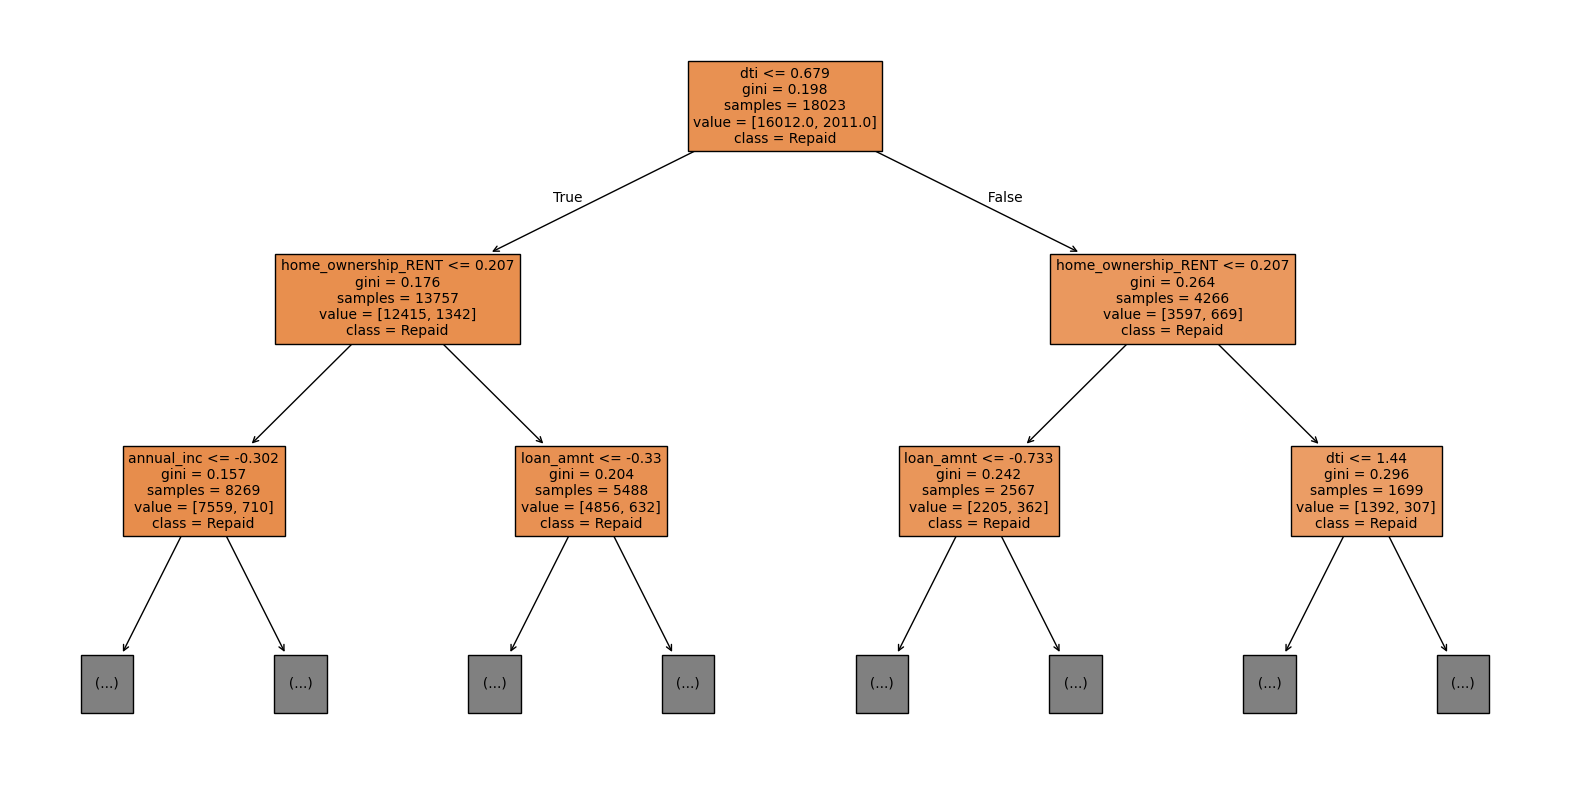

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Repaid', 'Default'], 
          filled=True,
          fontsize=10,
          max_depth=2) # We only show the top of the tree so it's readable
plt.show()

The decision tree identifies debt-to-income (dti) as the most critical factor for predicting loan outcomes, as it serves as the root split. It creates an hierarchy of risk, where borrowers with lower debt and stable housing (non-renters) are consistently filtered into the highest-probability "Repaid" class.

In [41]:
# Creating the data dictionary
# Replace 'log_reg_accuracy', 'log_reg_time', etc., with your actual variable names
results_data = {
    'Model': ['Logistic Regression', 'LDA', 'K-Nearest Neighbors', 'Decision Tree'],
    'Test Accuracy': [
        log_reg.score(X_test_scaled, y_test),
        lda_model.score(X_test_scaled, y_test),
        grid_search.score(X_test_scaled, y_test), # This uses your best K=20
        dt_model.score(X_test_scaled, y_test)
    ],
    'Training Time (s)': [
        log_reg_time, 
        lda_time, 
        cv_time, # Total time for the 10-fold CV search
        dt_cv_time
    ]
}

# Creating the DataFrame
df_results = pd.DataFrame(results_data)

# Displaying the table
df_results

,Model,Test Accuracy,Training Time (s)
0,Logistic Regression,0.885708,0.011976
1,LDA,0.885708,0.012007
2,K-Nearest Neighbors,0.886152,16.700068
3,Decision Tree,0.885264,0.239656


A notable finding is the consistency in testing accuracy across all four models, with each hovering around 88.5%. This suggests that the predictive power is likely limited by the features selected rather than the specific model used. For a creditor, this accuracy-ceiling indicates that moving to more complex models may not necessarily better identify high-risk borrowers without incorporating additional features into the model.

While the accuracy of all the models is similar, the efficiency may indicate which model is best for our dataset and objectives.

The logisitic regression and linear discriminant analysis models are the most efficient, training in a fraction of a second. This makes them ideal for high-volume environments where thousands of loan applications must be processed in real-time, given that the features are not too complex and do not require as much flexibility.

The decision tree was also a strong choice of model for this dataset. While slightly slower than the other models, it was highly efficient and offers the added benefit of interpretability, because we can see where the tree decides to split.

The training time for KNN is significantly higher at nearly 30 seconds. This is because the model selection process involved 10-fold cross-validation to optimize $K$. Since we had a list of 7 possible values of $K$, it runs 10 folds for 7 times, resulting in this long training time. While the training time for the optimal $K$ is likely similar to the other models, we felt that trying to optimize $K$ is a material burden that any lending institution would be subject to when using KNN, so we decided to include it.

## 3 Ensemble Methods

For this section, we will fit three ensemble classifiers on the same training data. First, a Random Forest, then an ADABoost, and finally an XGBoost.

As we learned in lecture 8, the reason we use ensemble models is to combat the high variance in decision trees. By combining many trees into an ensemble, we try to make the team of models stronger than an individual tree or model.

### 3.1 Fitting Models
#### 3.1.1 Random Forest

A random forest algorithm uses bagging combined with feature subsampling. This means it first draws a bootstrap sample, then grows a tree. At each split in the tree, it randomly selects features and finds the best split among those features, and repeats for each tree. The prediction is done by majority vote.

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import time

param_grid_rf = {
    'n_estimators': [100, 500, 1000], # Tested from 100-1000
    'max_depth': [10, 20,30, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

In [43]:
rf = RandomForestClassifier(
    oob_score=True,
    random_state=23,
    n_jobs=-1
)
start_rf = time.time()

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

end_rf = time.time()
rf_time = end_rf - start_rf

best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)


KeyboardInterrupt: 

In [ ]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)
print("AUC:", rf_auc)
print("Confusion Matrix:\n", rf_cm)
print("Training Time:", rf_time)

Accuracy: 0.8861517976031957
AUC: 0.6047918164780569
Confusion Matrix:
 [[3993    0]
 [ 513    0]]
Training Time: 362.306725025177


The hyperparameters we tuned for the random forest were number of estimators, max features, max depth, and minimum observations in a leaf.

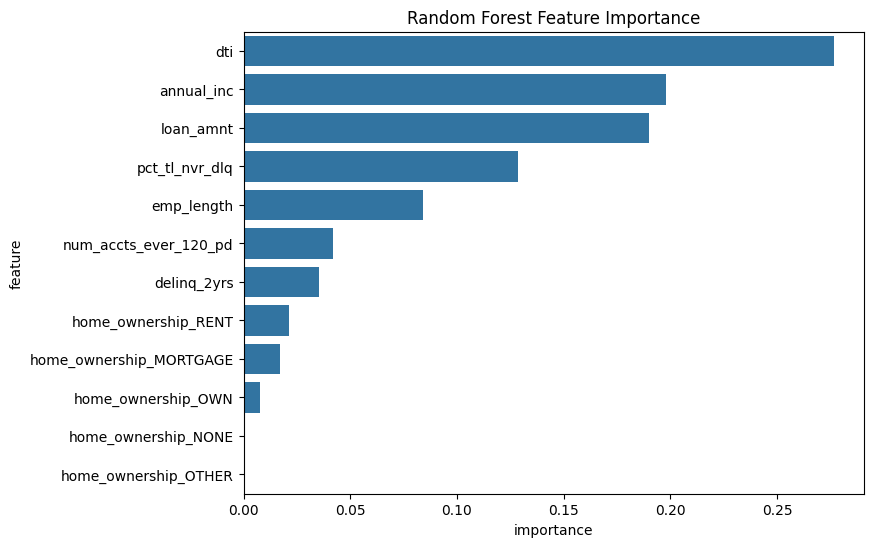

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.show()